# Plant Disease Prediction

## Importing Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


## Importing libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

### Building Convolution Layer

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load ResNet50 base (without top classification layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Build the Sequential model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1500, activation='relu'),     # Reduced units for better generalization
    Dropout(0.5),                        # Slightly higher dropout to avoid overfitting
    Dense(38, activation='softmax')     # Final classification layer
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Optional: Display summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,718,250 (101.92 MB)

 Trainable params: 3,130,538 (11.94 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compiling and Training Phase

In [8]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=20)

Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 465s 205ms/step - accuracy: 0.7565 - loss: 0.9118 - val_accuracy: 0.9607 - val_loss: 0.1352
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 272s 104ms/step - accuracy: 0.9516 - loss: 0.1564 - val_accuracy: 0.9711 - val_loss: 0.0905
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 266s 121ms/step - accuracy: 0.9663 - loss: 0.1046 - val_accuracy: 0.9729 - val_loss: 0.0782
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 322s 121ms/step - accuracy: 0.9740 - loss: 0.0794 - val_accuracy: 0.9771 - val_loss: 0.0659
Epoch 5/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 283s 103ms/step - accuracy: 0.9791 - loss: 0.0629 - val_accuracy: 0.9817 - val_loss: 0.0558
Epoch 6/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 226s 103ms/step - accuracy: 0.9835 - loss: 0.0514 - val_accuracy: 0.9816 - val_loss: 0.0522
Epoch 7/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 264s 120ms/step - accuracy: 0.9856 - loss: 0.0442 - val_accuracy: 0.9844 - val_loss: 0.0472
Epoch 8/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 265s 121ms/step - ac

## Evaluating Model

In [9]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 185s 84ms/step - accuracy: 0.9993 - loss: 0.0032
Training accuracy: 0.9993314146995544


In [10]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step - accuracy: 0.9902 - loss: 0.0356
Validation accuracy: 0.9882199168205261


### Saving Model

In [11]:
model.save('trained_plant_disease_model.keras')

In [12]:
training_history.history #Return Dictionary of history

{'accuracy': [0.8739739656448364,
  0.9561561942100525,
  0.9683192372322083,
  0.9753467440605164,
  0.980368435382843,
  0.9841382503509521,
  0.986343264579773,
  0.9888612031936646,
  0.9890745878219604,
  0.9904260635375977,
  0.9917490482330322,
  0.9920620322227478,
  0.9930578470230103,
  0.9936410784721375,
  0.9937548637390137,
  0.9943808317184448,
  0.9944661855697632,
  0.994423508644104,
  0.9954050779342651,
  0.995618462562561],
 'loss': [0.445839524269104,
  0.1412811577320099,
  0.09729915857315063,
  0.07501924782991409,
  0.059306059032678604,
  0.04946700111031532,
  0.04174477979540825,
  0.03496668487787247,
  0.03316866606473923,
  0.02842777594923973,
  0.02459469623863697,
  0.02279568277299404,
  0.020968222990632057,
  0.018804751336574554,
  0.01762746274471283,
  0.017167191952466965,
  0.01598583161830902,
  0.016499262303113937,
  0.01402403973042965,
  0.013016237877309322],
 'val_accuracy': [0.9606760740280151,
  0.9711472988128662,
  0.972911477088928

In [13]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [14]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

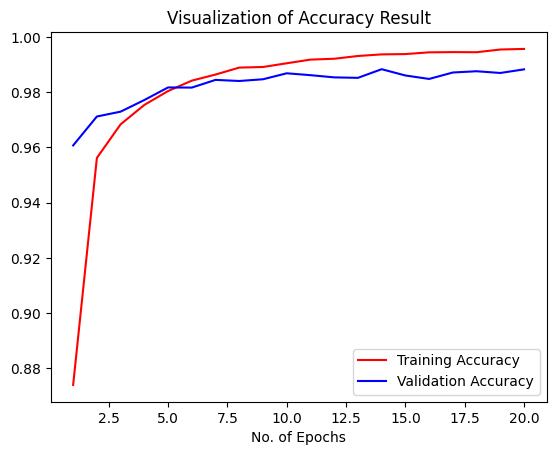

In [16]:
epochs = [i for i in range(1,21)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [17]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [19]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [20]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 163s 9ms/step


In [21]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [22]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [23]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [24]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [25]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       1.00      1.00      1.00       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.96      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.96      0.

### Confusion Matrix Visualization

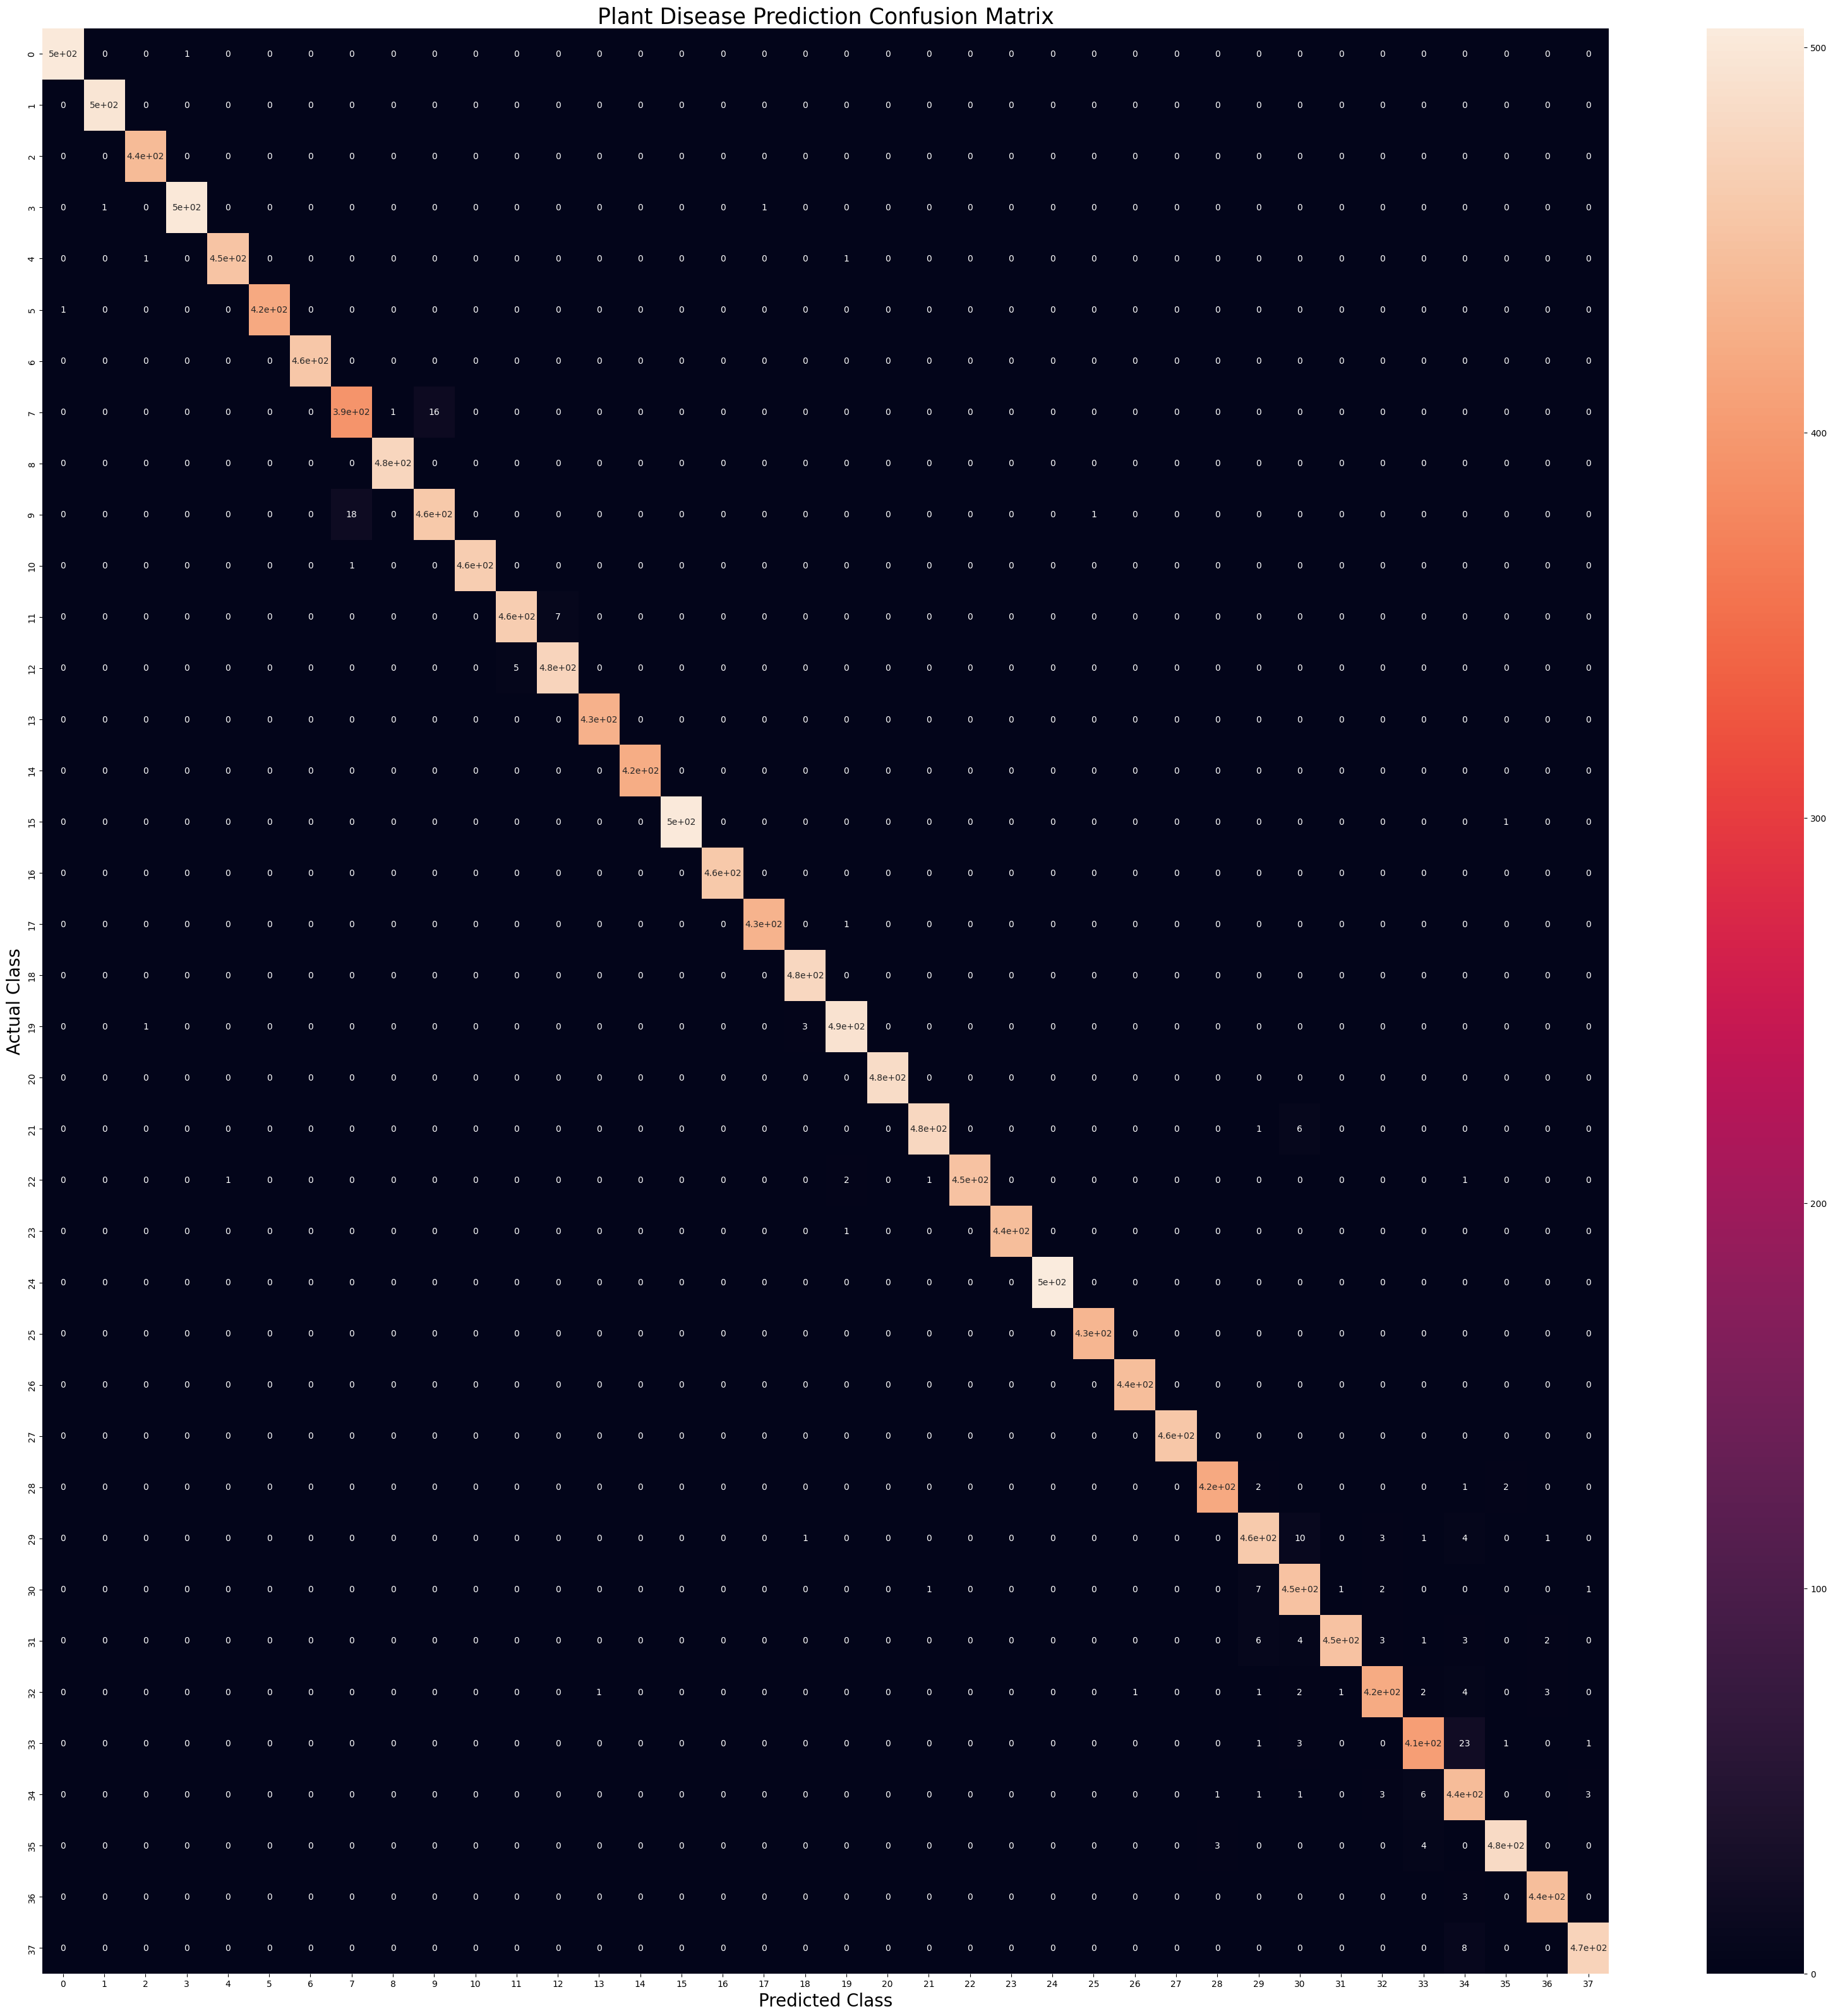

In [26]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()